# ResNet18 Prediction Distribution
Pass all images through a fully pretrained ResNet18 (ImageNet head intact) and explore what ImageNet classes it predicts for cloud vs clear_sky images.

In [1]:
from pathlib import Path
import os
import numpy as np
import cv2
from tqdm.auto import tqdm

IMAGES_PATH = Path("../resources/cloud-images/cloud-classifier-1")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images, cloud_labels
    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        cloud_labels.append(cloud_dir.name)
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {"label": cloud_dir.name, "path": str(img_path)}
    return labeled_images, cloud_labels

def load_rgb_images(labeled_images, size=(224, 224)):
    images, labels, names = [], [], []
    for image_name in tqdm(labeled_images, total=len(labeled_images)):
        path = labeled_images[image_name]['path']
        if not os.path.exists(path):
            continue
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, size)
        images.append(image)
        labels.append(labeled_images[image_name]['label'])
        names.append(image_name)
    return np.array(images), np.array(labels), np.array(names)

labeled_images, cloud_labels = index_labeled_images()
images, labels, image_names = load_rgb_images(labeled_images)
print(f"Loaded {len(images)} images — shape: {images.shape}, classes: {cloud_labels}")

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 698/698 [00:00<00:00, 1035.36it/s]

Loaded 698 images — shape: (698, 224, 224, 3), classes: ['clear_sky', 'cloud']


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet18_Weights

# Load fully pretrained ResNet18 — classification head intact
weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)
model.eval()

# ImageNet preprocessing (no grayscale conversion needed — images already RGB)
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ImageNet class labels
imagenet_classes = weights.meta["categories"]
print(f"Model loaded. {len(imagenet_classes)} ImageNet classes.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/lucasnseyep/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.55MB/s]

Model loaded. 1000 ImageNet classes.


In [3]:
import pandas as pd
from torch.nn.functional import softmax

BATCH_SIZE = 32
TOP_K = 5

records = []

with torch.no_grad():
    for start in tqdm(range(0, len(images), BATCH_SIZE)):
        batch_imgs   = images[start:start + BATCH_SIZE]
        batch_labels = labels[start:start + BATCH_SIZE]
        batch_names  = image_names[start:start + BATCH_SIZE]

        tensors = torch.stack([preprocess(img) for img in batch_imgs])
        probs   = softmax(model(tensors), dim=1)
        top_probs, top_idxs = probs.topk(TOP_K, dim=1)

        for i in range(len(batch_imgs)):
            record = {"image_name": batch_names[i], "label": batch_labels[i]}
            for k in range(TOP_K):
                record[f"top{k+1}_class"] = imagenet_classes[top_idxs[i, k].item()]
                record[f"top{k+1}_conf"]  = round(top_probs[i, k].item(), 4)
            records.append(record)

results_df = pd.DataFrame(records)
print(results_df.head())

100%|██████████| 22/22 [00:12<00:00,  1.77it/s]

     image_name      label top1_class  top1_conf top2_class  top2_conf  \
0    A_img1.png  clear_sky    sandbar     0.0510   seashore     0.0425   
1   A_img10.png  clear_sky   seashore     0.0525     beacon     0.0363   
2  A_img100.png  clear_sky     beacon     0.1432   seashore     0.1125   
3  A_img101.png  clear_sky   seashore     0.0578    sandbar     0.0556   
4  A_img102.png  clear_sky     beacon     0.1382   seashore     0.1072   

  top3_class  top3_conf top4_class  top4_conf         top5_class  top5_conf  
0     beacon     0.0277        alp     0.0265             geyser     0.0260  
1    sandbar     0.0321     geyser     0.0298          parachute     0.0294  
2    sandbar     0.0595     geyser     0.0397          parachute     0.0252  
3     geyser     0.0423     beacon     0.0347           flagpole     0.0283  
4     geyser     0.0755    sandbar     0.0367  drilling platform     0.0242  


## Visualisation 1: Top-15 Predicted ImageNet Classes per Category

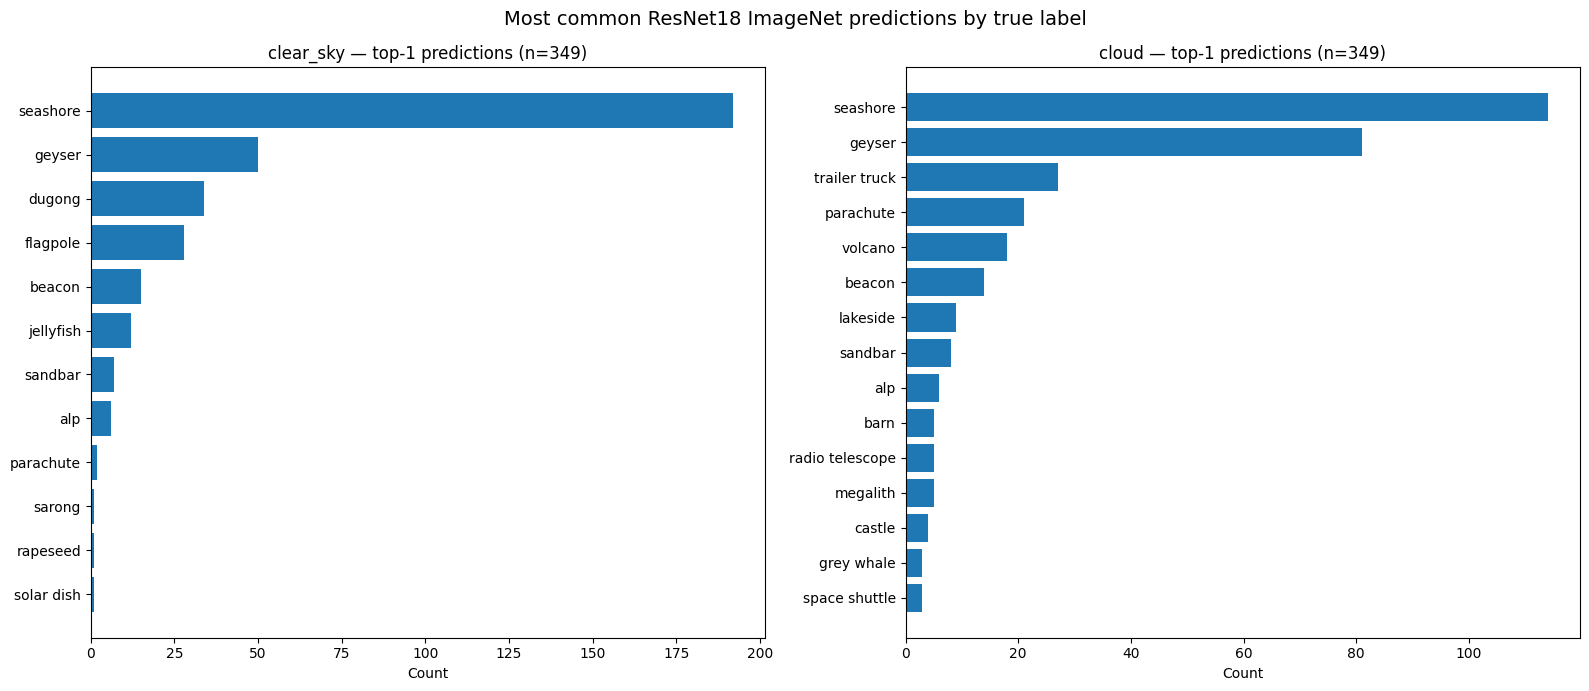

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, category in zip(axes, sorted(results_df['label'].unique())):
    counts = (
        results_df[results_df['label'] == category]['top1_class']
        .value_counts()
        .head(15)
        .sort_values()
    )
    ax.barh(counts.index, counts.values)
    ax.set_title(f"{category} — top-1 predictions (n={len(results_df[results_df['label'] == category])})", fontsize=12)
    ax.set_xlabel("Count")

plt.suptitle("Most common ResNet18 ImageNet predictions by true label", fontsize=14)
plt.tight_layout()
plt.show()

## Visualisation 2: Sample Images with Top-3 Predictions

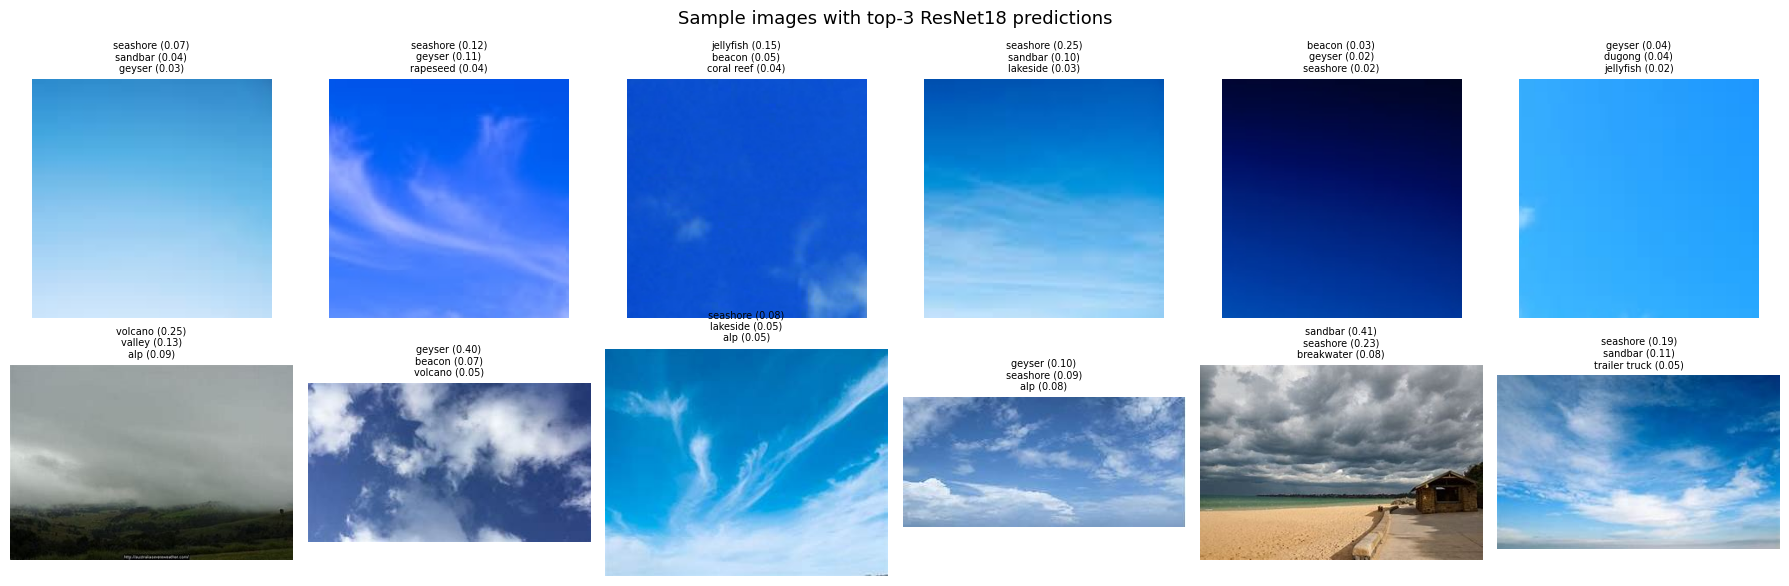

In [5]:
N_SAMPLES = 6
categories = sorted(results_df['label'].unique())

fig, axes = plt.subplots(len(categories), N_SAMPLES, figsize=(18, 6))

for row, category in enumerate(categories):
    cat_df = results_df[results_df['label'] == category].sample(N_SAMPLES, random_state=42)
    for col, (_, r) in enumerate(cat_df.iterrows()):
        img_path = labeled_images[r['image_name']]['path']
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        title = "\n".join([
            f"{r[f'top{k}_class']} ({r[f'top{k}_conf']:.2f})"
            for k in range(1, 4)
        ])
        axes[row, col].set_title(title, fontsize=7)

for row, category in enumerate(categories):
    axes[row, 0].set_ylabel(category, fontsize=11, labelpad=10)

plt.suptitle("Sample images with top-3 ResNet18 predictions", fontsize=13)
plt.tight_layout()
plt.show()

## Visualisation 3: Top-1 Confidence Distribution per Category

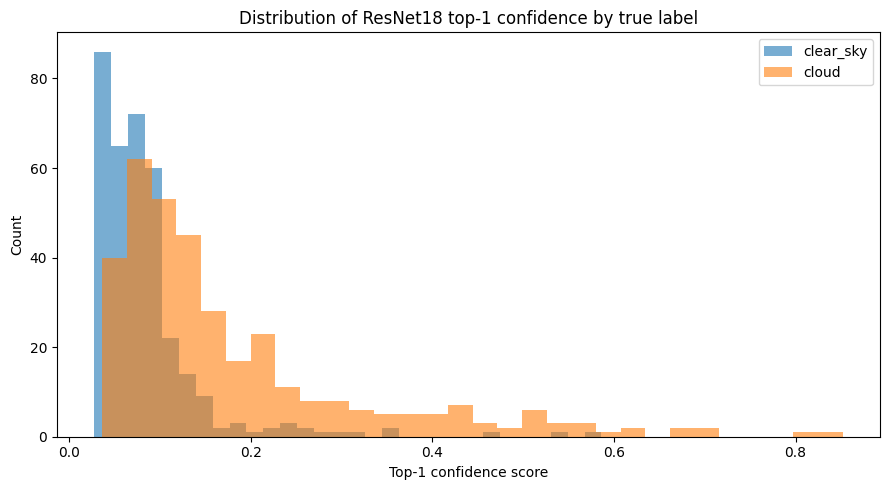

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for category in sorted(results_df['label'].unique()):
    confs = results_df[results_df['label'] == category]['top1_conf']
    ax.hist(confs, bins=30, alpha=0.6, label=category)

ax.set_xlabel("Top-1 confidence score")
ax.set_ylabel("Count")
ax.set_title("Distribution of ResNet18 top-1 confidence by true label")
ax.legend()
plt.tight_layout()
plt.show()